# Fashion Deep Learning Recommendation Systems

*Download the Dataset from here <a href=https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small>Dataset</a>
All the code is given. You need to download the data and train the model using the following code and save the model. Then, create a streamlit app to recommend similar products.

<img src="dataset-cover.png"/>

In [26]:
import numpy as np
import pickle as pkl
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPool2D

from sklearn.neighbors import NearestNeighbors
import os
from numpy.linalg import norm

In [27]:
data_path = 'myntradataset/images' 
filenames = []
for file in os.listdir(data_path):
    filenames.append(os.path.join(data_path, file))

In [28]:
len(filenames)

44441

In [29]:
#Importing ResNet50 Model and Cofiguration
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
model.trainable = False

model = tf.keras.models.Sequential([model, GlobalMaxPool2D()])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [30]:
#Extracting Fetaures from Image
def extract_features_from_images(image_path, model):
    img = image.load_img(image_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_expand_dim = np.expand_dims(img_array, axis=0)
    img_preprocess = preprocess_input(img_expand_dim)
    result = model.predict(img_preprocess).flatten()
    norm_result = result/norm(result)
    return norm_result

In [31]:
extract_features_from_images(filenames[0], model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([0.        , 0.01761618, 0.00171608, ..., 0.01247238, 0.02726405,
       0.06899219], shape=(2048,), dtype=float32)

In [32]:
image_features = []
for file in filenames[0:1000]:
    image_features.append(extract_features_from_images(file, model))
image_features

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━

[array([0.        , 0.01761618, 0.00171608, ..., 0.01247238, 0.02726405,
        0.06899219], shape=(2048,), dtype=float32),
 array([0.        , 0.03648943, 0.        , ..., 0.00997914, 0.02375535,
        0.04649905], shape=(2048,), dtype=float32),
 array([0.        , 0.03507714, 0.00732279, ..., 0.00283509, 0.        ,
        0.05435884], shape=(2048,), dtype=float32),
 array([0.00232166, 0.0503055 , 0.00747743, ..., 0.00346685, 0.03391017,
        0.04565744], shape=(2048,), dtype=float32),
 array([0.00306836, 0.06240449, 0.        , ..., 0.00170624, 0.02032886,
        0.0583326 ], shape=(2048,), dtype=float32),
 array([0.        , 0.10469182, 0.00198064, ..., 0.        , 0.03033056,
        0.0271293 ], shape=(2048,), dtype=float32),
 array([0.        , 0.12438457, 0.01465613, ..., 0.00289705, 0.04055161,
        0.06534588], shape=(2048,), dtype=float32),
 array([0.        , 0.09169203, 0.01569911, ..., 0.        , 0.0050358 ,
        0.04560041], shape=(2048,), dtype=float32),


In [33]:
Image_features = pkl.dump(image_features, open('Images_features.pkl','wb'))

In [34]:
filenames = pkl.dump(filenames, open('filenames.pkl','wb'))

In [35]:
#Loading Pickle Files

In [36]:
Image_features = pkl.load(open('Images_features.pkl','rb'))

In [37]:
filenames = pkl.load(open('filenames.pkl','rb'))

In [38]:
np.array(Image_features).shape

(1000, 2048)

In [39]:
#Finidng Simialar Images

In [40]:
neighbors = NearestNeighbors(n_neighbors=6, algorithm='brute', metric='euclidean')

In [41]:
neighbors.fit(Image_features)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=6)

In [42]:
input_image = extract_features_from_images('images/16871.jpg',model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [43]:
distance,indices = neighbors.kneighbors([input_image])

In [44]:
indices[0]

array([519, 525, 520, 195, 524, 215])

In [45]:
from IPython.display import Image

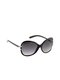

In [46]:
Image('images/16871.jpg')

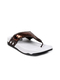

In [47]:
Image(filenames[indices[0][1]])

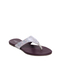

In [48]:
Image(filenames[indices[0][2]])

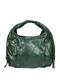

In [49]:
Image(filenames[indices[0][3]])

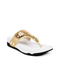

In [50]:
Image(filenames[indices[0][4]])

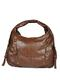

In [51]:
Image(filenames[indices[0][5]])